In [45]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(0)

## Scaling

In [ ]:
'''

১.Scaling কী?
   ডেটাসেটের বিভিন্ন feature-এর range ভিন্ন হলে (যেমন: Age = 20-80, Salary = 20,000-1,00,000), Distance-based বা Gradient-based মডেলগুলো (যেমন KNN, Neural Networks) বড় range-এর feature-কে (যেমন Salary) গাণিতিকভাবে বেশি গুরুত্ব দেয়। Scaling হলো numerical feature-গুলোকে একটি নির্দিষ্ট range (সাধারণত 0 থেকে 1) এর মধ্যে নিয়ে আসার প্রক্রিয়া।
    
   Important: Scaling সাধারণত data-এর distribution-এর shape পরিবর্তন করে না। Data আগে skewed হলে scaling-এর পরেও skewed থাকবে।



২. Min-Max Scaling
   সবচেয়ে common scaling technique-এর একটি হলো Min-Max Scaling। formula: X_scaled = (X - X_min) / (X_max - X_min)

   যেখানে:
   X → Original data value
   X_min → feature-এর সবচেয়ে ছোট value
   X_max → feature-এর সবচেয়ে বড় value
   X_scaled → Scaling-এর পরের value

   Defaultভাবে Min-Max Scaling data-কে 0 থেকে 1 range-এ নিয়ে আসে।



৪. Train-Test Data Leakage: ML-এ সবচেয়ে গুরুত্বপূর্ণ নিয়ম: Train data-এর min/max ব্যবহার করেই Test data scale করতে হবে। Test data-এর নিজের min/max দিয়ে scale করা যাবে না। কারণ এতে Test data-এর information training process-এ indirectly চলে আসতে পারে, যাকে Data Leakage বলে। Scikit-Learn-এর scaler object fit করা values save করে রাখে বলে এই process সহজ ও নিরাপদভাবে করা যায়।


৫. Formula vs Scikit-Learn: Manual formula দিয়ে scaling করা সম্ভব. কিন্তু practical ML project-এ `MinMaxScaler` বেশি সুবিধাজনক কারণ:
         - min এবং max automatically calculate ও store করে
         - Train/Test scaling-এর সময় একই parameters reuse করা সহজ
         - নতুন unseen data-তেও একই scaler ব্যবহার করা যায়
         - ML Pipeline-এর সাথে সহজে ব্যবহার করা যায়
         - Manual implementation-এর তুলনায় ভুল হওয়ার সম্ভাবনা কম


'''
pass

In [20]:
# ei code e 1000 ta random exponential distribution er data generate kora hobe.
# iccha korei exponential distribution er data generate kora hoise. karon exponential distribution er graph right skewed hoy. so scaling er aage and pore graph dekhe porve kroa jabe je scaling er karone distribution change hoy ni.

data = np.random.exponential(size = 1000)

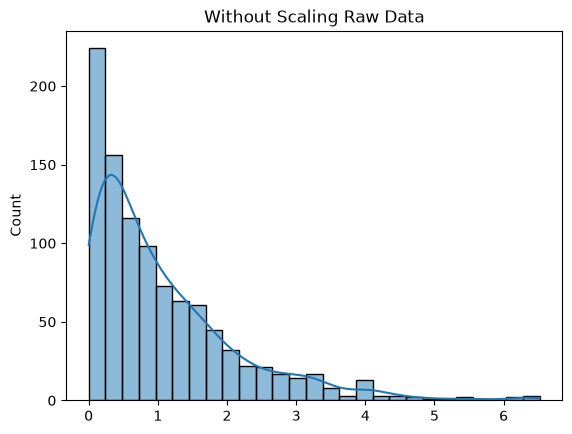

In [34]:
sns.histplot(data = data, kde=True)
plt.title("Without Scaling Raw Data")
plt.show()

### with formula

In [ ]:
# Calculate Min and Max of the dataset
minimum_value = np.min(data)
maximum_value = np.max(data)

# Apply Min-Max Scaling Formula 
scaled_data_with_formula = (data - minimum_value) / (maximum_value - minimum_value)

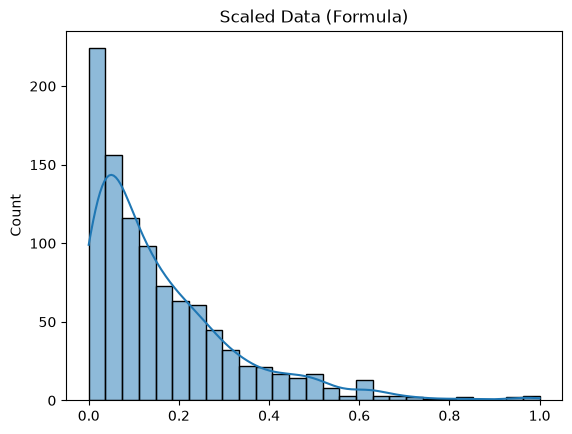

In [42]:
sns.histplot(scaled_data_with_formula, kde=True)
plt.title("Scaled Data (Formula)")
plt.show()

### with scikit-learn

In [43]:
# for min_max scaling import MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

In [ ]:
# scikit-learn 2d array expect kore. so ami data ke 2d array te convert korbo.

data_2d = data.reshape(-1, 1)

In [ ]:
'''
    scaler = MinMaxScaler() -> eta scikit-learn theke import kora object. etar moddhei fit() and transform() method ache.
    scaler.fit(data_2d) ->  find min and max
    scaler.transform(data_2d) ->  min, max peye gesi ekhon transform(formula)
'''

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data_2d) # fit and transform evabe shortcut e likha hoy.

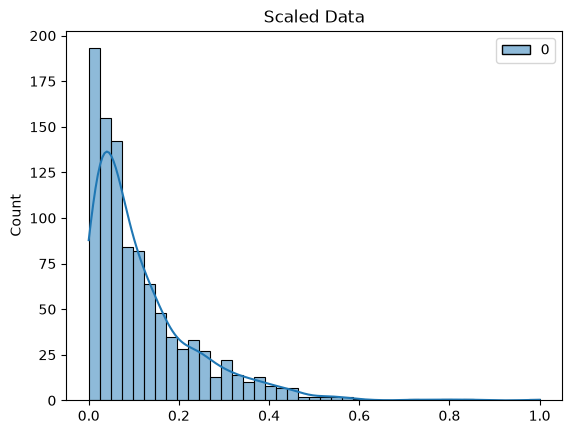

In [ ]:
sns.histplot(data = scaled_data, kde=True)
plt.title("Scaled Data")
plt.show()

## Normalization

In [ ]:
'''
১. Normalization কী? (ডকুমেন্টেশনের আলোকে)
Scaling শুধুমাত্র ডেটার range পরিবর্তন করে, কিন্তু Normalization অনেক বেশি র‍্যাডিক্যাল একটি পরিবর্তন। এর মূল উদ্দেশ্য হলো তোমার ডেটার distribution-এর shape বা আকার পরিবর্তন করে তাকে Normal distribution (বা Bell curve)-এ রূপান্তর করা।

Normal distribution-এর বৈশিষ্ট্য হলো—বেশিরভাগ ডেটা mean-এর কাছাকাছি থাকে এবং গ্রাফটি দেখতে symmetric bell shaped  হয়।

২. এটি কেন এবং কখন ব্যবহার করা হয়?
তুমি যখন এমন কোনো Machine Learning বা Statistics টেকনিক ব্যবহার করবে যা গাণিতিকভাবে ধরে নেয় (assumes) যে তোমার ইনপুট ডেটা normally distributed, তখন Normalization ব্যবহার করতে হয়। উদাহরণস্বরূপ: Linear Discriminant Analysis (LDA) এবং Gaussian Naive Bayes। ডকুমেন্টেশনের প্রো-টিপ অনুযায়ী: যে অ্যালগরিদমের নামে "Gaussian" শব্দটি আছে, সেটি সাধারণত normal distribution আশা করে।

3. Normalization-এর জন্য সাধারণত Box-Cox বা Yeo-Johnson Transformation ব্যবহার করা হয়। Box-Cox transformation শুধুমাত্র positive values-এর জন্য কাজ করে, কিন্তু Yeo-Johnson transformation negative values-ও handle করতে পারে।
'''

pass

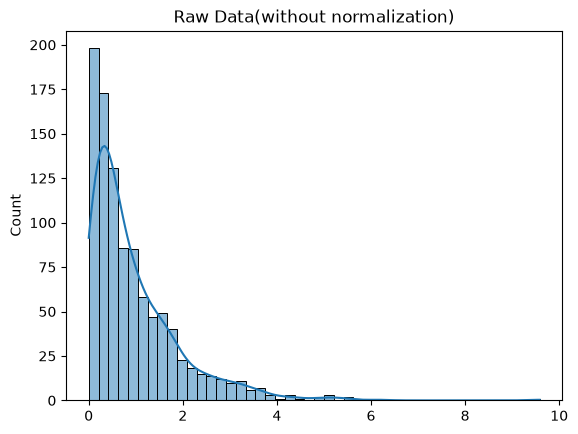

In [51]:
from sklearn.preprocessing import PowerTransformer

data = np.random.exponential(size=1000).reshape(-1, 1)

sns.histplot(data = data, kde=True, legend=False)
plt.title("Raw Data(without normalization)")
plt.show()

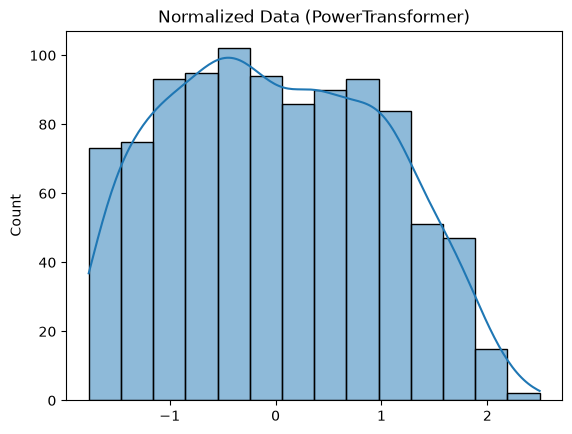

In [52]:
pt = PowerTransformer(method='yeo-johnson')
normalized_data = pt.fit_transform(data)

sns.histplot(data = normalized_data, kde=True, legend=False)
plt.title("Normalized Data (PowerTransformer)")
plt.show()